In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Tao anh gia RGB 300x400
img_rgb = np.random.randint(0,256,(300,400,3), dtype = np.uint8)

#Tao gradient grayscale de test histogram
gradient = np.linspace(0,255,300*400).reshape(300,400).astype(np.uint8)

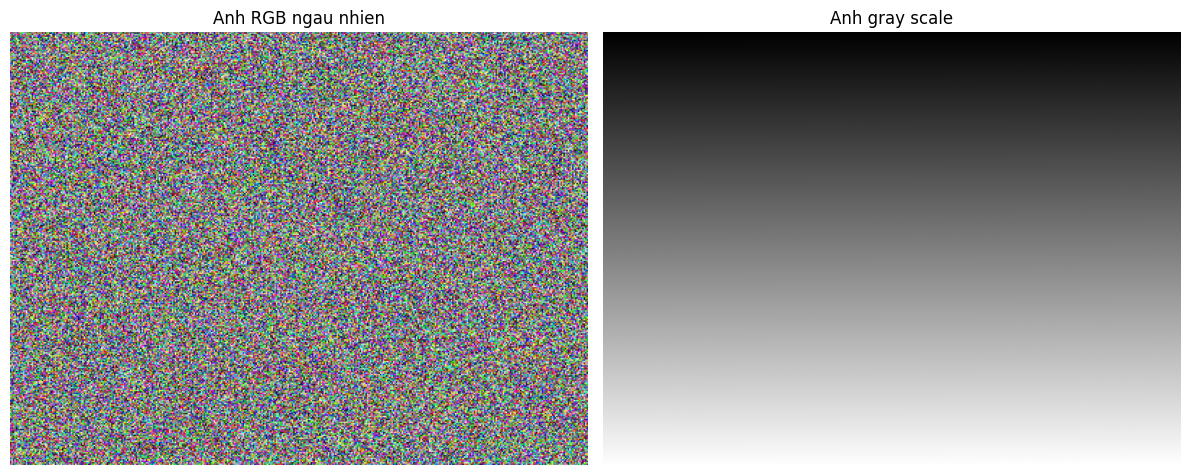

In [2]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].imshow(img_rgb)
axes[0].set_title("Anh RGB ngau nhien")
axes[0].axis("off") #An truc so

axes[1].imshow(gradient, cmap="gray") #Anh grat scale
axes[1].set_title("Anh gray scale")
axes[1].axis("off")

import os
os.makedirs("results", exist_ok=True)  # Tạo thư mục nếu chưa có

plt.tight_layout()
plt.savefig("results/day3_imshow.png", dpi=150, bbox_inches="tight")
plt.show()


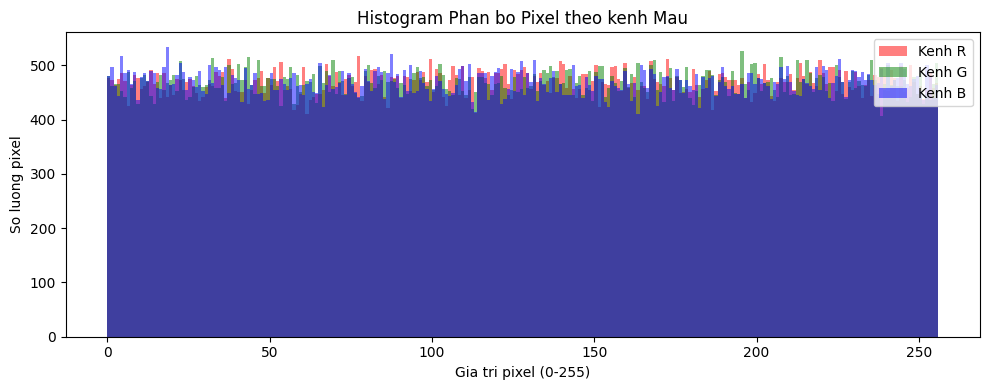

In [3]:

fig, ax = plt.subplots(figsize=(10,4))

colors = ["red", "green", "blue"]
channel_names = ["Kenh R", "Kenh G", "Kenh B"]

for i, (color, name) in enumerate(zip(colors, channel_names)):
    ax.hist(img_rgb[:,:,i].ravel(), # Flatten kenh thanh 1D
            bins =256,
            range=(0,256),
            color=color,
            alpha = 0.5,
            label=name)

ax.set_xlabel("Gia tri pixel (0-255)")
ax.set_ylabel("So luong pixel")
ax.set_title("Histogram Phan bo Pixel theo kenh Mau")
ax.legend()
plt.tight_layout()
plt.savefig("results/day3_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
def visualize_image(img : np.darray,
                    title: str = "Image",
                    show_histogram: bool = True,
                    save_path: str = None) -> None:
    """
    Hiển thị ảnh kèm histogram phân bố pixel.
    Args:
        img: numpy array (H, W, 3) hoặc (H,W) - giá trị [0,255] hoặc [0,1]
        title: Tiêu đề hiển thị
        show_histogram: Có vẽ histogram kèm không,
        save_path : Đường dẫn lưu ảnh (None = không lưu)
    """
    #Chuẩn hóa về [0,255] nếu ảnh ở dạng float [0,1]
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = (img * 255).astype(np.uint8)

    is_gray = img.ndim == 2
    ncols = 2 if show_histogram else 1

    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols,5))
    if ncols == 1:
        axes = [axes]

    #Panel anh
    cmap = "gray" if is_gray else None
    axes[0].imshow(img, cmap = cmap)
    axes[0].set_title(title)
    axes[0].axis("off")

    #Panel histogram
    if show_histogram:
        if is_gray:
            axes[1].hist(img.ravel(), bins=256, range=(0,256), color="gray",alpha =0.7)
        else:
            for i, color in enumerate(["red","green","blue"]):
                axes[1].hist(img[:,:,i].ravel(), bins=256, range=(0,256), color=color, alpha=0.5,
                             label=color.upper())
            axes[1].legend()
            axes[1].set_title("Histogram")
            axes[1].set_xlabel('Giá trị pixel')
            axes[1].set_ylabel('Số lượng pixel')
        plt.suptitle(title, fontsize=14, fontweight="bold")
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"Da luu: {save_path}")
        plt.show()
        plt.close()
           
        
